## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## 1. Importación de librerías

Se importan las herramientas necesarias para manipular datos, crear gráficas, dividir el conjunto, escalar variables, entrenar el modelo y evaluarlo.

In [1]:
# Importar librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Carga del dataset

Se carga el dataset **Adult Income** utilizando la misma forma sencilla empleada en el Lab11.  
Si el archivo `adult.csv` ya se encuentra en la carpeta del notebook, se utiliza directamente; de lo contrario, se descarga mediante KaggleHub.

In [2]:
# Buscar el archivo en la carpeta actual
if os.path.exists("adult.csv"):
    path = "."
else:
    path = kagglehub.dataset_download(
        "uciml/adult-census-income"
    )

print("Ruta del dataset:", path)

dfAdult = pd.read_csv(
    path + "/adult.csv"
)

dfAdult.head()

100%|██████████| 450k/450k [00:00<00:00, 679kB/s]

Extracting files...
Ruta del dataset: C:\Users\gaela\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Comprensión del problema y de las variables

La variable objetivo es `income`. Esta indica si una persona gana:

- `<=50K`: 50,000 dólares o menos al año.
- `>50K`: más de 50,000 dólares al año.

Las demás columnas contienen información demográfica, educativa y laboral que puede ayudar a realizar la predicción.

In [3]:
# Revisamos la información del dataset
dfAdult.info()

print("\nColumnas:")
print(dfAdult.columns.tolist())

print("\nDistribución de la variable objetivo:")
dfAdult["income"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB

Columnas:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

## 4. Exploración inicial de datos (EDA)

Se revisan las dimensiones, los registros duplicados, las estadísticas generales y la distribución de algunas variables relevantes.

In [4]:
print("Número de registros:", dfAdult.shape[0])
print("Número de columnas:", dfAdult.shape[1])
print("Registros duplicados:", dfAdult.duplicated().sum())

dfAdult.describe()

Número de registros: 32561
Número de columnas: 15
Registros duplicados: 24


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


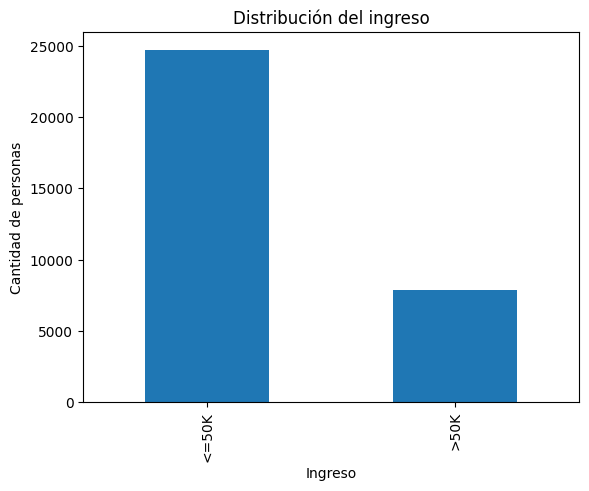

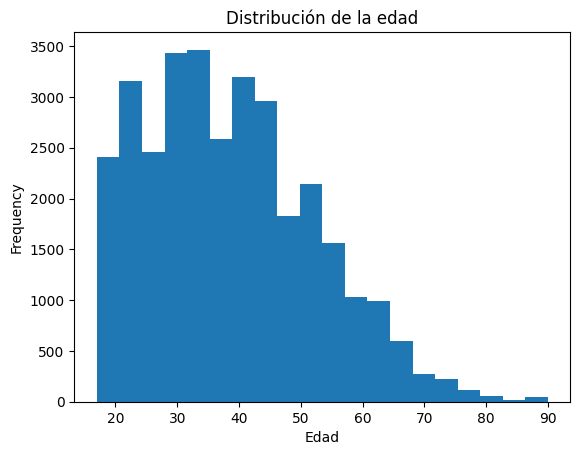

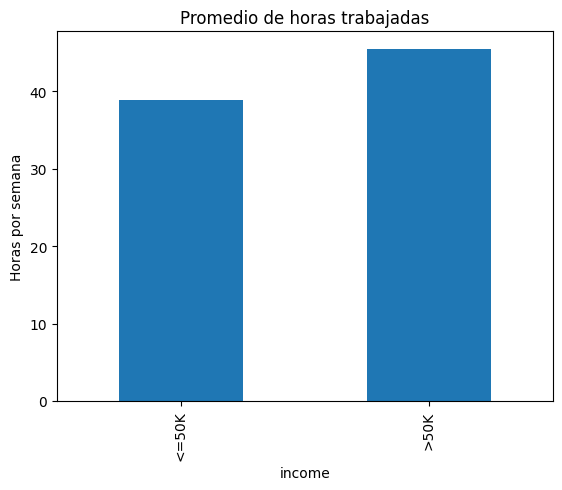

In [5]:
# Distribución de la variable objetivo
dfAdult["income"].value_counts().plot(
    kind="bar"
)
plt.title("Distribución del ingreso")
plt.xlabel("Ingreso")
plt.ylabel("Cantidad de personas")
plt.show()

# Distribución de la edad
dfAdult["age"].plot(
    kind="hist",
    bins=20
)
plt.title("Distribución de la edad")
plt.xlabel("Edad")
plt.show()

# Promedio de horas trabajadas según el ingreso
dfAdult.groupby(
    "income"
)["hours.per.week"].mean().plot(
    kind="bar"
)
plt.title("Promedio de horas trabajadas")
plt.ylabel("Horas por semana")
plt.show()

## 5. Tratamiento de valores nulos

En este dataset algunos datos faltantes aparecen con el símbolo `?`.  
Primero se reemplazan por `NaN` y después se completan utilizando la moda, de la misma manera que en el Lab11.

In [6]:
# Convertimos ? en valores nulos
dfAdult = dfAdult.replace(
    "?",
    np.nan
)

print("Valores nulos antes de completar:")
print(dfAdult.isnull().sum())

# Completamos las columnas con datos faltantes
dfAdult["workclass"] = dfAdult["workclass"].fillna(
    dfAdult["workclass"].mode()[0]
)

dfAdult["occupation"] = dfAdult["occupation"].fillna(
    dfAdult["occupation"].mode()[0]
)

dfAdult["native.country"] = dfAdult["native.country"].fillna(
    dfAdult["native.country"].mode()[0]
)

print("\nValores nulos después de completar:")
dfAdult.isnull().sum()

Valores nulos antes de completar:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Valores nulos después de completar:


age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## 6. Correlación e hipótesis iniciales

Para calcular la correlación, la variable `income` se transforma temporalmente en números:

- `0`: <=50K
- `1`: >50K

**Hipótesis:** la edad, la educación, las horas trabajadas, el estado civil, la ocupación y las ganancias de capital podrían influir en el ingreso.

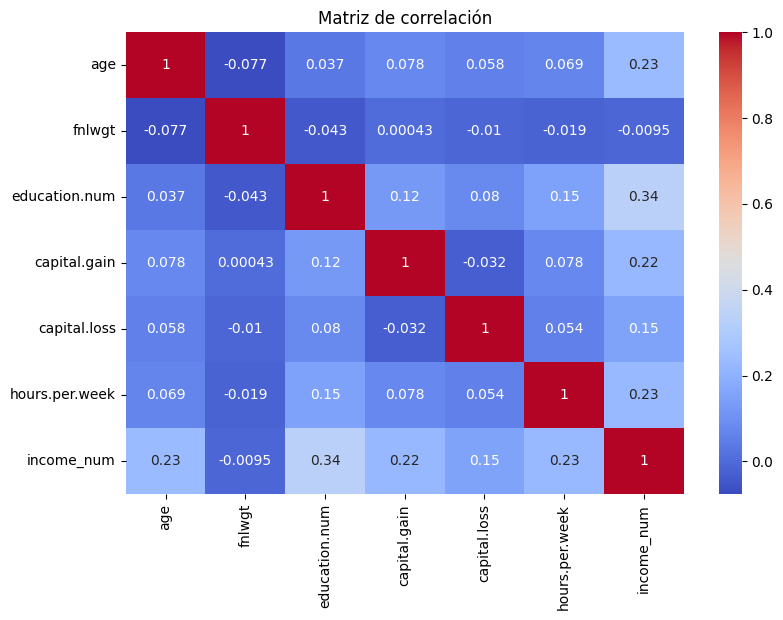

In [7]:
# Creamos una columna numérica para el ingreso
dfAdult["income_num"] = dfAdult["income"].map({
    "<=50K": 0,
    ">50K": 1
})

variables_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "income_num"
]

corr = dfAdult[variables_numericas].corr()

plt.figure(figsize=(9,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

# Eliminamos la columna auxiliar
dfAdult = dfAdult.drop(
    columns=["income_num"]
)

## 7. Variables predictoras y variable objetivo

Se seleccionan las 14 variables que utilizará el modelo y se separa la variable objetivo `income`.

- `X`: variables predictoras.
- `y`: variable que queremos predecir.

In [8]:
columnas = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country"
]

X = dfAdult[columnas]

y = dfAdult["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']

Variable objetivo:
income


## 8. One-Hot Encoding

Los algoritmos no entienden directamente las palabras. Por eso, las variables categóricas se convierten en columnas numéricas mediante `pd.get_dummies()`, igual que en el Lab11.

In [9]:
columnas_categoricas = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country"
]

columnas_antes = X.shape[1]

X = pd.get_dummies(
    X,
    columns=columnas_categoricas,
    drop_first=True
)

columnas_despues = X.shape[1]

print("Columnas antes:", columnas_antes)
print("Columnas después:", columnas_despues)
print("Columnas adicionales:", columnas_despues - columnas_antes)

X.head()

Columnas antes: 14
Columnas después: 97
Columnas adicionales: 83


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


## 9. División en entrenamiento y prueba

Los datos se dividen de la siguiente manera:

- 80% para entrenamiento.
- 20% para prueba.

Así se evalúa el modelo con registros que no utilizó durante el entrenamiento.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (26048, 97)
Prueba: (6513, 97)


## 10. Estandarización con StandardScaler

Las variables numéricas tienen escalas diferentes. Se utiliza `StandardScaler` para colocarlas en una escala similar.

El escalador se ajusta con los datos de entrenamiento y después se aplica a los datos de prueba.

In [11]:
columnas_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

scaler = StandardScaler()

X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

X_train[columnas_numericas].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,-1.753989e-16,-1.009294e-16,1.421195e-16,-2.291369e-17,-4.146287e-17,8.729026e-18
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.584336e+00,-1.690420e+00,-3.521699e+00,-1.471664e-01,-2.176795e-01,-3.204476e+00
25%,-7.747588e-01,-6.842442e-01,-4.217268e-01,-1.471664e-01,-2.176795e-01,-4.208134e-02
50%,-1.123775e-01,-1.078053e-01,-3.423025e-02,-1.471664e-01,-2.176795e-01,-4.208134e-02
75%,6.236017e-01,4.534354e-01,1.128259e+00,-1.471664e-01,-2.176795e-01,3.633539e-01
max,3.788312e+00,1.205002e+01,2.290749e+00,1.315328e+01,1.049046e+01,4.742055e+00


## 11. Entrenamiento del Árbol de Decisión

Se utiliza un Árbol de Decisión con una profundidad máxima de 4, igual que en el ejemplo del Lab11.

In [12]:
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

modelo.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## 12. Predicciones

El modelo realiza predicciones utilizando los datos de prueba.

In [13]:
predicciones = modelo.predict(
    X_test
)

pd.DataFrame({
    "Valor real": y_test,
    "Predicción": predicciones
}).head(30)

,Valor real,Predicción
14160,0,0
27048,0,0
28868,0,0
5667,0,0
7827,0,0
15382,0,0
4641,0,0
8943,0,0
216,0,0
5121,0,0


## 13. Evaluación: Accuracy, matriz de confusión y reporte de clasificación

El `Accuracy` indica el porcentaje de predicciones correctas.  
También se muestran la matriz de confusión y el reporte de clasificación para observar los aciertos y errores de cada clase.

Accuracy: 0.8449
Porcentaje: 84.49%

Matriz de confusión:
[[4728  248]
 [ 762  775]]


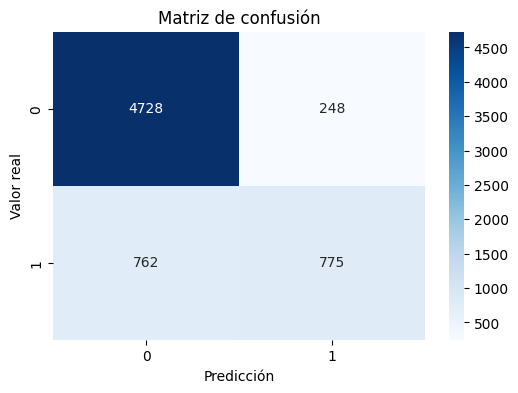

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4976
           1       0.76      0.50      0.61      1537

    accuracy                           0.84      6513
   macro avg       0.81      0.73      0.75      6513
weighted avg       0.84      0.84      0.83      6513



In [14]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Porcentaje: {accuracy * 100:.2f}%")

matriz = confusion_matrix(
    y_test,
    predicciones
)

print("\nMatriz de confusión:")
print(matriz)

plt.figure(figsize=(6,4))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

print("Reporte de clasificación:")
print(classification_report(
    y_test,
    predicciones
))

### Interpretación de la matriz de confusión

- **4,728** personas con ingreso `<=50K` fueron clasificadas correctamente.
- **775** personas con ingreso `>50K` fueron clasificadas correctamente.
- **248** personas con ingreso `<=50K` fueron clasificadas incorrectamente como `>50K`.
- **762** personas con ingreso `>50K` fueron clasificadas incorrectamente como `<=50K`.

El modelo identifica mejor a las personas de la clase `<=50K`, porque esta clase contiene más registros.

## 14. Importancia de las variables (Feature Importance)

Se revisan las variables que el Árbol de Decisión utilizó con mayor frecuencia para realizar sus predicciones, siguiendo el mismo procedimiento del Lab11.

In [15]:
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo.feature_importances_
})

importancias_ordenadas = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias_ordenadas.head(15)

,Variable,Importancia
29,marital.status_Married-civ-spouse,0.491686
2,education.num,0.248290
3,capital.gain,0.225830
4,capital.loss,0.021809
0,age,0.011251
1,fnlwgt,0.000966
37,occupation_Farming-fishing,0.000167
7,workclass_Never-worked,0.000000
5,hours.per.week,0.000000
9,workclass_Self-emp-inc,0.000000


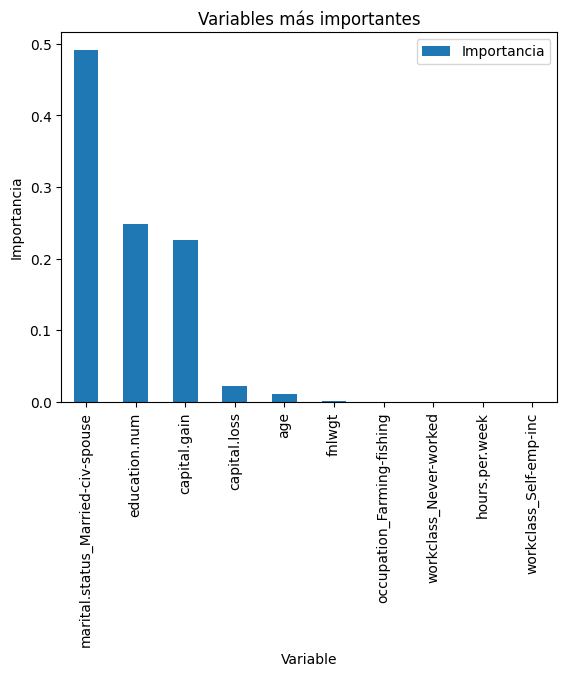

Variable más importante:
Variable       marital.status_Married-civ-spouse
Importancia                             0.491686
Name: 29, dtype: object

Cantidad de variables con importancia igual a cero:
90


In [16]:
# Graficamos las 10 variables más importantes
importancias_ordenadas.head(10).plot(
    x="Variable",
    y="Importancia",
    kind="bar"
)
plt.title("Variables más importantes")
plt.ylabel("Importancia")
plt.show()

print("Variable más importante:")
print(importancias_ordenadas.iloc[0])

print("\nCantidad de variables con importancia igual a cero:")
print((importancias_ordenadas["Importancia"] == 0).sum())

### Visualización parcial del árbol

Para que la imagen sea entendible, se muestran únicamente los primeros tres niveles del Árbol de Decisión.

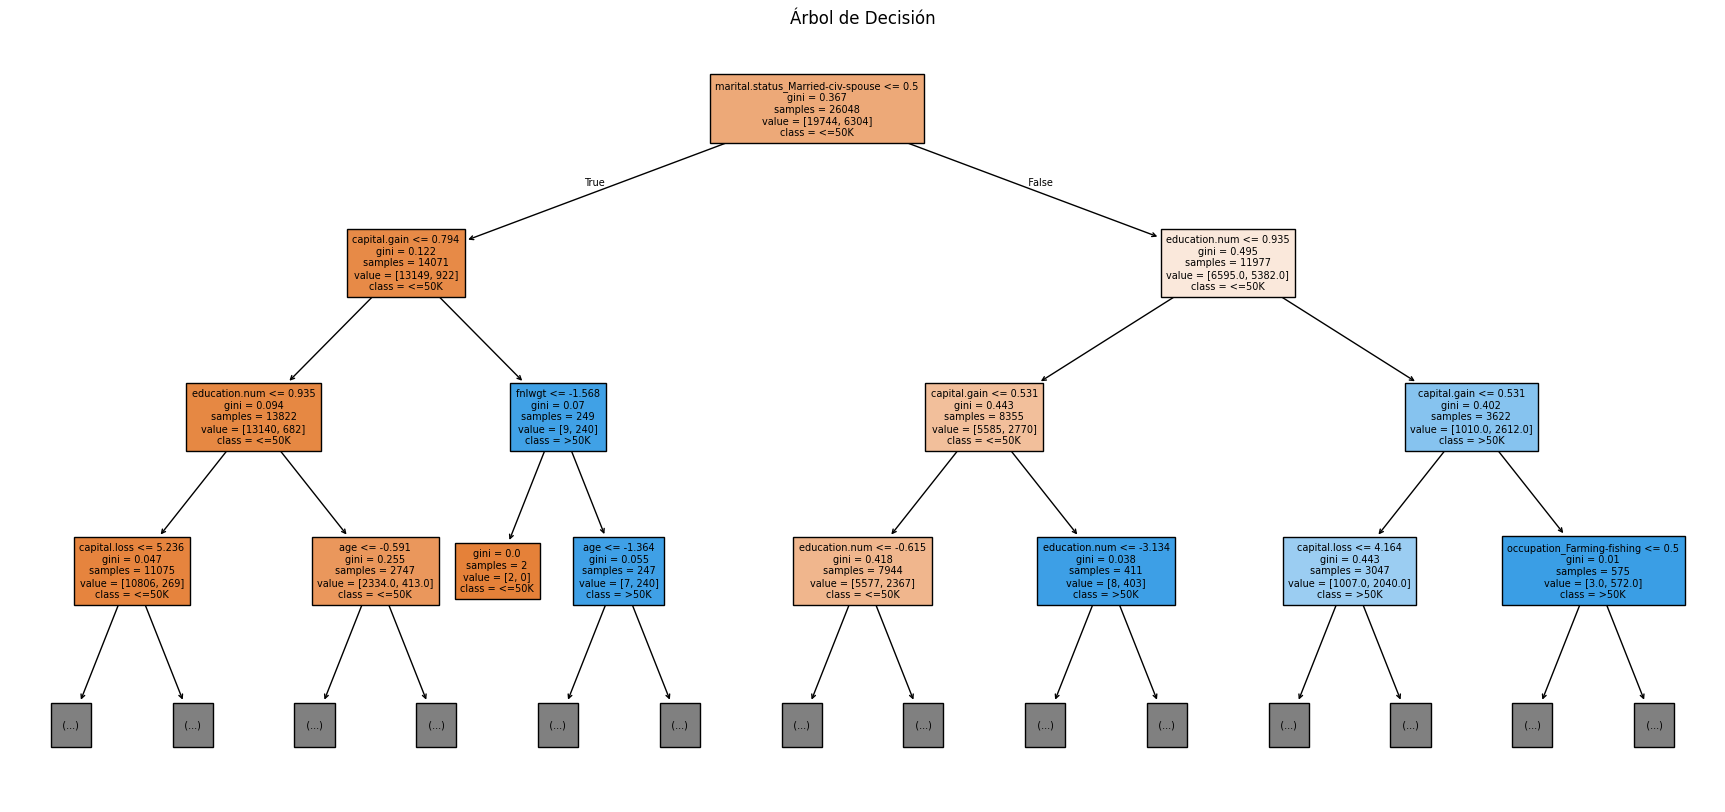

In [17]:
plt.figure(figsize=(22,10))

plot_tree(
    modelo,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    fontsize=7
)

plt.title("Árbol de Decisión")
plt.show()

## Preguntas

1. ¿Cuál es la variable objetivo? La variable objetivo es income.
2. ¿Qué representa dicha variable? Representa si una persona gana **50,000 dólares o menos (`<=50K`)** o **más de 50,000 dólares (`>50K`)** al año.
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona? La edad, el nivel educativo, la ocupación, el estado civil, las horas trabajadas y las ganancias de capital.
4. ¿Cuántas variables predictoras existen? Existen **14 variables predictoras originales**.
5. ¿Por qué fue necesario transformar variables categóricas? Porque el modelo necesita trabajar con números. `pd.get_dummies()` convierte las categorías de texto en columnas numéricas.
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding? Antes había **14 columnas** y después quedaron **97**, por lo que se generaron **83 columnas adicionales**.
8. ¿Existen valores nulos? Sí. Los valores faltantes estaban representados con `?`: **1,836** en `workclass`, **1,843** en `occupation` y **583** en `native.country`. Después de completarlos con la moda quedaron **0 valores nulos**.
9. ¿Qué variables son numéricas? `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss` y `hours.per.week`.
10. ¿Qué variables son categóricas? `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex` y `native.country`.
11. ¿Cuántos registros quedaron en entrenamiento? Quedaron **26,048 registros**.
12. ¿Cuántos registros quedaron en prueba? Quedaron **6,513 registros**.
13. ¿Por qué no debemos entrenar utilizando todos los datos? Porque necesitamos una parte de los datos que el modelo no haya visto para comprobar si realmente puede realizar buenas predicciones.
14. ¿Cuál fue el Accuracy obtenido? El Accuracy fue **0.8449**, equivalente a **84.49%**.
15. ¿Consideras que el resultado es adecuado? Sí. Es un resultado adecuado para un primer modelo de Árbol de Decisión, aunque todavía puede mejorarse.
16. ¿Qué factores podrían afectar el desempeño del modelo? El desbalance de las clases, los datos faltantes, la profundidad del árbol, la selección de variables y la cantidad de información disponible.
18. ¿Cuál fue la variable más importante? La variable codificada más importante fue **`marital.status_Married-civ-spouse`**.
19. ¿Cuál fue la menos importante? No existe una sola variable menos importante, porque **90 variables obtuvieron importancia igual a cero** en este árbol. Entre ellas se encuentra `hours.per.week` y varias categorías creadas por One-Hot Encoding.
20. ¿Coinciden los resultados con tus hipótesis iniciales? Sí. El estado civil, el nivel educativo, las ganancias de capital y la edad aparecen entre las variables con mayor importancia.
21. ¿Qué variables aportan más información al modelo? Las que más información aportaron fueron `marital.status_Married-civ-spouse`, `education.num`, `capital.gain`, `capital.loss`, `age`, `fnlwgt` y `occupation_Farming-fishing`.


## 16. Conclusiones

1. El dataset contiene **32,561 registros**, 14 variables predictoras y una variable objetivo.
2. Se identificaron valores faltantes representados con `?` y se completaron utilizando la moda.
3. Las variables categóricas se transformaron con `pd.get_dummies()` y se obtuvieron **97 columnas predictoras**.
4. Los datos se dividieron en 80% para entrenamiento y 20% para prueba.
5. Las variables numéricas se estandarizaron mediante `StandardScaler`.
6. El Árbol de Decisión obtuvo un **Accuracy de 84.49%**.
7. La variable más importante fue `marital.status_Married-civ-spouse`.
8. El modelo funciona de manera adecuada como una primera solución, aunque puede mejorarse ajustando sus parámetros o probando otros algoritmos.

**Resultado general:** se completaron todas las indicaciones del Lab12 utilizando una forma de trabajo y comandos similares a los empleados en el Lab11.

# Entregable

```text
Notebooks/
└── Laboratorio12.ipynb
```

El notebook contiene todas las indicaciones del Lab12, el código ejecutado, las gráficas, las respuestas y las conclusiones.